In [ ]:
from torch.utils.data import DataLoader

from src.dataset.snow import SnowDataset

snow_dataset = SnowDataset(
    dataset_dir_path='/Users/samuelthomas/Documents/University/4thYr_Final'
                     '/ECM3401_Individual_Literature_Review_and_Project/SNOW_Semantic_Segmentation'
                     '/snow_dataset',
    len_override=10000,
    resize=True,
    rotate=True,
    normalize=True,
)
train_loader = DataLoader(snow_dataset, batch_size=2, shuffle=True, num_workers=1)

images, masks = next(iter(train_loader))

from PIL import Image as _Image


def print_tensor_mask(x):
    tensor = x.detach().cpu().squeeze(0).numpy()
    tensor = (tensor * 255).astype(np.uint8)
    mask_image = _Image.fromarray(tensor, mode='L')
    return mask_image


def print_tensor_image(x):
    image_np = x.detach().cpu().permute(1, 2, 0).numpy()
    image_np = (image_np * 255).astype(np.uint8)
    image = _Image.fromarray(image_np)
    return image

In [ ]:
import torch

x = torch.rand(1, 256, 1024)
kwargs = {'start_dim': 1, 'end_dim': -1}
x1 = x.flatten(**kwargs)
x1.shape

In [12]:
import torch
import torch.nn as nn

x1 = torch.randn(10, 512, 32, 32)

x = nn.Conv2d(512, 1024, kernel_size=2, stride=2)(x1)  # 32x32 -> 16x16
print(x.shape)
nn.BatchNorm2d(1024)(x).shape

torch.Size([10, 1024, 16, 16])


torch.Size([10, 1024, 16, 16])

In [28]:
import torch

x = torch.randn(10, 256, 1024)

B, N, C = x.shape
H = W = int(N ** 0.5)
x = x.reshape(B, C, H, W)
x.shape

torch.Size([10, 1024, 16, 16])

In [18]:

import torch.nn as _nn

final_num_patches = 1024
final_embed_dim = 512
output_dims = (1, 512, 512)

# Compute the number of operations required to reach the final resolution
resolution = int(final_num_patches ** 0.5)
resolution_ = resolution
num_classes, H, W = output_dims
num_operations = 0
while resolution_ < H:
    resolution_ *= 2
    num_operations += 1

# Compute the best factor to reduce the final embedding dimension
best_factor = final_embed_dim // num_operations
while final_embed_dim % best_factor != 0:
    best_factor += 1

# Compute the dimensions of the transposed convolutions
dim = final_embed_dim
transposed_dims = [dim]
for i in range(num_operations):
    dim_ = dim - best_factor
    if dim_ <= 0:
        dim //= 2
    else:
        dim = dim_
    transposed_dims.append(dim)

# Create the transposed convolutions
transposed_convolutions = _nn.Sequential()
for i in range(len(transposed_dims) - 1):
    dim_1 = transposed_dims[i]
    dim_2 = transposed_dims[i + 1]
    transposed_convolutions.append(
        _nn.ConvTranspose2d(dim_1, dim_2, kernel_size=2, stride=2)
    )
    transposed_convolutions.append(_nn.ReLU())

# Add the final transposed convolution to predict the number of classes and a ReLU activation
prediction_head = _nn.Conv2d(transposed_dims[-1], num_classes, kernel_size=1, stride=1)

In [19]:
transposed_convolutions

Sequential(
  (0): ConvTranspose2d(512, 384, kernel_size=(2, 2), stride=(2, 2))
  (1): ReLU()
  (2): ConvTranspose2d(384, 256, kernel_size=(2, 2), stride=(2, 2))
  (3): ReLU()
  (4): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (5): ReLU()
  (6): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
  (7): ReLU()
)

In [39]:
import typing as _t

import torch as _torch
import torch.nn as _nn


class Decoder(_nn.Module):
    """
    Decoder module that will upsample the final patch embedding to the output dimensions.
    """

    def __init__(
            self,
            up_sample_to_common_scale_convs: _t.Dict[str, _nn.Module],
            final_embedding_up_sample_convs: _nn.Sequential,
            prediction_head: _nn.Module,
    ) -> None:
        """

        :param up_sample_to_common_scale_convs: Transposed convolutions to upsample the embeddings to a common scale.
        :param final_embedding_up_sample_convs: Transposed convolutions to upsample the embeddings.
        :param prediction_head: Prediction head to predict the output.
        """

        super(Decoder, self).__init__()
        self.__up_sample_to_common_scale_convs = up_sample_to_common_scale_convs
        self.__final_embedding_up_sample_convs = final_embedding_up_sample_convs
        self.__prediction_head = prediction_head

        self.__initialize_weights()

    @classmethod
    def create(
            cls,
            patch_embedding_scales: _t.List[_t.Tuple[int, int]],
            output_dims: _t.Tuple[int, int, int]
    ) -> 'Decoder':
        """
        Create a decoder that will upsample the final embeddings to the output dimensions.

        :param patch_embedding_scales:
        :param output_dims:
        :return:
        """
        patch_embedding_scales = sorted(patch_embedding_scales, key=lambda x: x[0])
        final_patch_size = patch_embedding_scales[0][0]
        final_embed_dim = patch_embedding_scales[0][1]

        up_sample_to_common_scale_convs = {}
        for i, patch_embedding_dim in enumerate(patch_embedding_scales[:-1], start=1):
            patch_size = patch_embedding_dim[0]
            embed_dim = patch_embedding_dim[1]
            scale_factor = final_patch_size // patch_size
            up_sample_to_common_scale_convs[f"x{i}"] = (
                _nn.ConvTranspose2d(embed_dim, final_embed_dim, kernel_size=scale_factor, stride=scale_factor)
            )

        # Compute the number of operations required to reach the final resolution
        resolution_ = final_patch_size
        num_classes, H, W = output_dims
        num_operations = 0
        while resolution_ < H:
            resolution_ *= 2
            num_operations += 1

        # Compute the best factor to reduce the final embedding dimension
        best_factor = final_embed_dim // num_operations
        while final_embed_dim % best_factor != 0:
            best_factor += 1

        # Compute the dimensions of the transposed convolutions
        dim = final_embed_dim
        transposed_dims = [dim]
        for i in range(num_operations):
            dim_ = dim - best_factor
            if dim_ <= 0:
                dim //= 2
            else:
                dim = dim_
            transposed_dims.append(dim)

        # Create the transposed convolutions
        final_embedding_up_sample_convs = _nn.Sequential()
        for i in range(len(transposed_dims) - 1):
            dim_1 = transposed_dims[i]
            dim_2 = transposed_dims[i + 1]
            final_embedding_up_sample_convs.append(
                _nn.ConvTranspose2d(dim_1, dim_2, kernel_size=2, stride=2)
            )
            final_embedding_up_sample_convs.append(_nn.ReLU())

        # Add the final transposed convolution to predict the number of classes and a ReLU activation
        prediction_head = _nn.Conv2d(transposed_dims[-1], num_classes, kernel_size=1, stride=1)

        return cls(
            up_sample_to_common_scale_convs=up_sample_to_common_scale_convs,
            final_embedding_up_sample_convs=final_embedding_up_sample_convs,
            prediction_head=prediction_head
        )

    @property
    def prediction_head(self) -> _nn.Module:
        """
        Get the prediction head of the decoder

        :return: Prediction head.
        """
        return self.__prediction_head

    def forward(self, patch_embeddings: _t.Dict[str, _torch.Tensor]) -> _torch.Tensor:
        """
        Forward pass of the decoder to up sample and apply prediction head to a patch embedding tensor.

        :param patch_embeddings: Patch embeddings to up sample.
        :return: Predicted output tensor.
        """
        prediction_head = self.__prediction_head

        # Upsample to the final resolution
        final_embedding = self._forward_(patch_embeddings)

        # Apply the prediction head
        x = prediction_head(final_embedding)

        return x

    def _forward_(self, patch_embeddings: _t.Dict[str, _torch.Tensor]) -> _torch.Tensor:
        """
        Forward pass of the decoder to up sample and apply prediction head to a patch embedding tensor.

        :param patch_embeddings: Patch embeddings to up sample.
        :return: The final embedding tensor.
        """
        up_sample_to_common_scale_convs = self.__up_sample_to_common_scale_convs
        final_embedding_up_sample_convs = self.__final_embedding_up_sample_convs
        prediction_head = self.__prediction_head

        # Fuse the patch embeddings to a common scale
        final_embedding = list(patch_embeddings.values())[-1]
        for key, conv in up_sample_to_common_scale_convs.items():
            patch_embedding = patch_embeddings[key]
            # - Reshape into a 2D tensor
            B, N, C = patch_embedding.shape
            H = W = int(N ** 0.5)
            patch_embedding = patch_embedding.reshape(B, C, H, W)
            # - Upsample to a common scale
            final_embedding = final_embedding + conv(patch_embedding)

        # Upsample to the final resolution
        final_embedding = final_embedding_up_sample_convs(final_embedding)

        return final_embedding

    def __initialize_weights(self) -> None:
        """
        Initialize the weights of the decoder.
        """
        final_embedding_up_sample_convs = self.__final_embedding_up_sample_convs
        up_sample_to_common_scale_convs = self.__up_sample_to_common_scale_convs
        prediction_head = self.__prediction_head

        for layer in final_embedding_up_sample_convs:
            if isinstance(layer, _nn.ConvTranspose2d):
                _nn.init.xavier_uniform_(layer.weight)
                _nn.init.constant_(layer.bias, 0)

        for layer in up_sample_to_common_scale_convs.values():
            _nn.init.xavier_uniform_(layer.weight)
            _nn.init.constant_(layer.bias, 0)

        _nn.init.xavier_uniform_(prediction_head.weight)
        _nn.init.constant_(prediction_head.bias, 0)

In [46]:
patch_embedding_scales = [(32, 1024), (16, 768), (8, 512)]
output_dims = (1, 512, 512)

patch_embedding_scales = sorted(patch_embedding_scales, key=lambda x: x[0])
final_patch_size = patch_embedding_scales[0][0]
final_embed_dim = patch_embedding_scales[0][1]

up_sample_to_common_scale_convs = {}
for i, patch_embedding_dim in enumerate(patch_embedding_scales[1:], start=1):
    patch_size = patch_embedding_dim[0]
    embed_dim = patch_embedding_dim[1]
    scale_factor = patch_size // final_patch_size
    up_sample_to_common_scale_convs[f"x{i}"] = (
        _nn.ConvTranspose2d(embed_dim, final_embed_dim, kernel_size=scale_factor, stride=scale_factor)
    )

# Compute the number of operations required to reach the final resolution
resolution_ = final_patch_size
num_classes, H, W = output_dims
num_operations = 0
while resolution_ < H:
    resolution_ *= 2
    num_operations += 1

# Compute the best factor to reduce the final embedding dimension
best_factor = final_embed_dim // num_operations
while final_embed_dim % best_factor != 0:
    best_factor += 1

# Compute the dimensions of the transposed convolutions
dim = final_embed_dim
transposed_dims = [dim]
for i in range(num_operations):
    dim_ = dim - best_factor
    if dim_ <= 0:
        dim //= 2
    else:
        dim = dim_
    transposed_dims.append(dim)

# Create the transposed convolutions
final_embedding_up_sample_convs = _nn.Sequential()
for i in range(len(transposed_dims) - 1):
    dim_1 = transposed_dims[i]
    dim_2 = transposed_dims[i + 1]
    final_embedding_up_sample_convs.append(
        _nn.ConvTranspose2d(dim_1, dim_2, kernel_size=2, stride=2)
    )
    final_embedding_up_sample_convs.append(_nn.ReLU())

# Add the final transposed convolution to predict the number of classes and a ReLU activation
prediction_head = _nn.Conv2d(transposed_dims[-1], num_classes, kernel_size=1, stride=1)

In [47]:
final_embedding_up_sample_convs

Sequential(
  (0): ConvTranspose2d(512, 384, kernel_size=(2, 2), stride=(2, 2))
  (1): ReLU()
  (2): ConvTranspose2d(384, 256, kernel_size=(2, 2), stride=(2, 2))
  (3): ReLU()
  (4): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (5): ReLU()
  (6): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
  (7): ReLU()
  (8): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
  (9): ReLU()
  (10): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
  (11): ReLU()
)

In [48]:
up_sample_to_common_scale_convs

{'x1': ConvTranspose2d(768, 512, kernel_size=(2, 2), stride=(2, 2)),
 'x2': ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(4, 4))}

In [49]:
x = torch.randn(10, 512, 8, 8)
final_embedding_up_sample_convs(x).shape

torch.Size([10, 16, 512, 512])

In [ ]:
from src.dataset.snow_extended import SnowDataset

snow_dataset = SnowDataset(
    dataset_dir_path='/Users/samuelthomas/Documents/University/4thYr_Final'
                     '/ECM3401_Individual_Literature_Review_and_Project/SNOW_Semantic_Segmentation'
                     '/snow_dataset',
    len_override=5,
    resize=True,
)

In [ ]:
image_1, mask_1 = snow_dataset[0]
print(image_1.shape)

In [ ]:
image_2, mask_2 = snow_dataset[6]
print(image_1.shape)

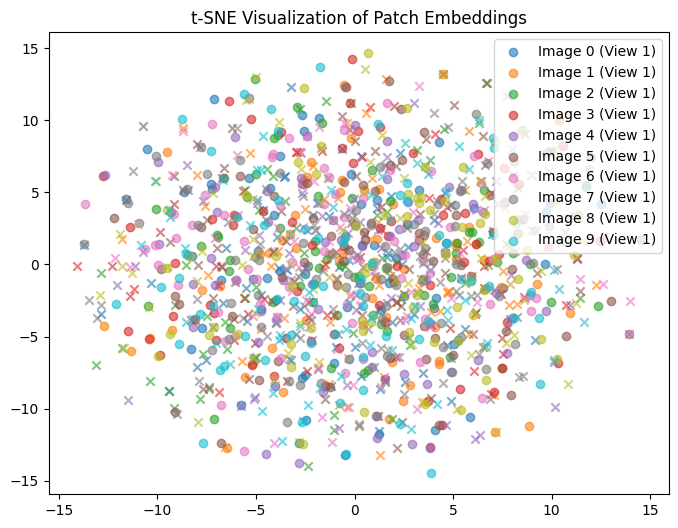

In [1]:
import torch


def visualize_tsne(x1, x2, num_images=10, title="t-SNE Visualization of Patch Embeddings"):
    """
    Visualizes patch embeddings using t-SNE with positive and negative pairs.

    :param x1: Patch embeddings for first augmented view, shape [B, P, E]
    :param x2: Patch embeddings for second augmented view, shape [B, P, E]
    :param num_images: Number of images to plot for clarity.
    :param title: Title of the plot.
    """
    B, P, E = x1.shape  # Batch, Patches, Embedding Dim

    # Flatten patch embeddings to [B*P, E]
    x1_flat = x1.view(B * P, E).cpu().numpy()
    x2_flat = x2.view(B * P, E).cpu().numpy()

    # Combine embeddings for t-SNE visualization
    embeddings = np.concatenate([x1_flat, x2_flat], axis=0)  # Shape: [2B*P, E]

    # Create labels
    labels = np.concatenate([np.arange(B).repeat(P), np.arange(B).repeat(P)])  # Shape: [2B*P]

    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(8, 6))
    cmap = plt.get_cmap("tab10")  # Different colors for different images

    for i in range(num_images):  # Only plot a subset for clarity
        idxs_x1 = np.where(labels == i)[0][:P]  # First augmentation
        idxs_x2 = np.where(labels == i)[0][P:2 * P]  # Second augmentation

        plt.scatter(embeddings_2d[idxs_x1, 0], embeddings_2d[idxs_x1, 1], color=cmap(i), label=f'Image {i} (View 1)',
                    alpha=0.6, marker='o')
        plt.scatter(embeddings_2d[idxs_x2, 0], embeddings_2d[idxs_x2, 1], color=cmap(i), alpha=0.6, marker='x')

    plt.legend()
    plt.title(title)
    plt.show()


# Example usage
B, P, E = 16, 64, 128  # Example batch size, patches, embedding dim
x1 = torch.randn(B, P, E)  # Simulated patch embeddings for first view
x2 = torch.randn(B, P, E)  # Simulated patch embeddings for second view

visualize_tsne(x1, x2, num_images=10)


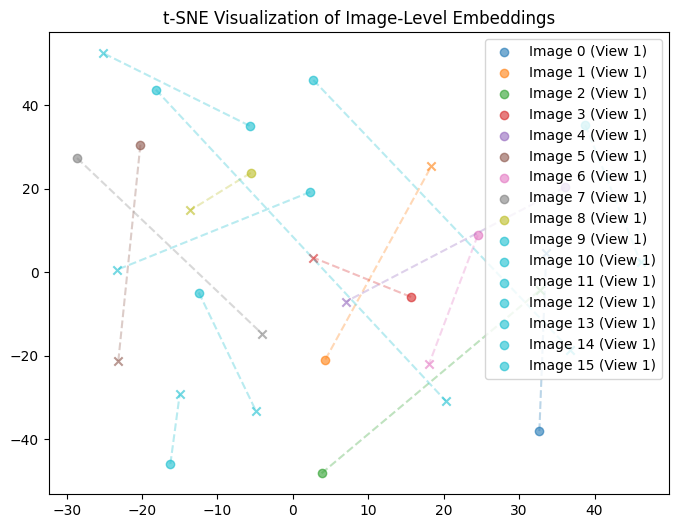

In [6]:
import torch


def visualize_tsne(x1, x2, title="t-SNE Visualization of Image-Level Embeddings"):
    """
    Visualizes image-level embeddings using t-SNE, where each image is represented as a single point.

    :param x1: Patch embeddings for first augmented view, shape [B, P, E]
    :param x2: Patch embeddings for second augmented view, shape [B, P, E]
    :param title: Title of the plot.
    """
    B, P, E = x1.shape  # Batch, Patches, Embedding Dim

    # Compute mean patch embedding per image [B, E]
    x1_avg = x1.mean(dim=1).cpu().numpy()  # Averaging over patches
    x2_avg = x2.mean(dim=1).cpu().numpy()

    # Combine embeddings for t-SNE visualization [2B, E]
    embeddings = np.concatenate([x1_avg, x2_avg], axis=0)

    # Create labels: Each image gets a unique label
    labels = np.concatenate([np.arange(B), np.arange(B)])  # Shape: [2B]

    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=10, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(8, 6))
    cmap = plt.get_cmap("tab10")  # Different colors for different images

    for i in range(B):  # Each image
        idx_x1, idx_x2 = i, B + i  # First and second augmentation indices

        plt.scatter(embeddings_2d[idx_x1, 0], embeddings_2d[idx_x1, 1], color=cmap(i), label=f'Image {i} (View 1)',
                    alpha=0.6, marker='o')
        plt.scatter(embeddings_2d[idx_x2, 0], embeddings_2d[idx_x2, 1], color=cmap(i), alpha=0.6, marker='x')

        # Draw line connecting views of the same image
        plt.plot([embeddings_2d[idx_x1, 0], embeddings_2d[idx_x2, 0]],
                 [embeddings_2d[idx_x1, 1], embeddings_2d[idx_x2, 1]],
                 color=cmap(i), alpha=0.3, linestyle="--")

    plt.legend()
    plt.title(title)
    plt.show()


# Example usage
B, P, E = 16, 64, 128  # Example batch size, patches, embedding dim
x1 = torch.randn(B, P, E)  # Simulated patch embeddings for first view
x2 = torch.randn(B, P, E)  # Simulated patch embeddings for second view

visualize_tsne(x1, x2)


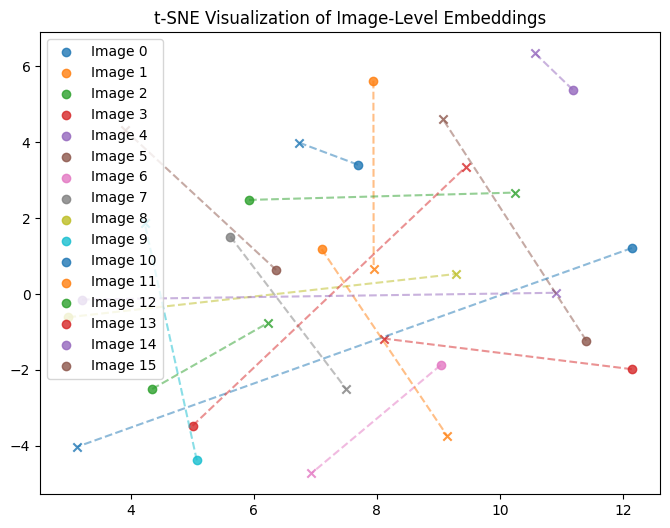

In [2]:
import torch
from sklearn.manifold import TSNE


def visualize_tsne(x1, x2, title="t-SNE Visualization of Image-Level Embeddings"):
    """
    Visualizes image-level embeddings using t-SNE, where each image is represented as a single point.

    :param x1: Patch embeddings for first augmented view, shape [B, P, E]
    :param x2: Patch embeddings for second augmented view, shape [B, P, E]
    :param title: Title of the plot.
    """
    B, P, E = x1.shape  # Batch, Patches, Embedding Dim

    # Compute mean patch embedding per image [B, E]
    x1_avg = x1.mean(dim=1).cpu().numpy()  # Averaging over patches
    x2_avg = x2.mean(dim=1).cpu().numpy()

    # Combine embeddings for t-SNE visualization [2B, E]
    embeddings = np.concatenate([x1_avg, x2_avg], axis=0)

    # Create labels: Each image gets a unique label
    labels = np.concatenate([np.arange(B), np.arange(B)])  # Shape: [2B]

    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=10, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Define a distinct color for each image
    cmap = plt.get_cmap("tab10")  # "tab10" has 10 distinct colors
    colors = [cmap(i % 10) for i in range(B)]  # Assign each image a unique color

    # Plot
    plt.figure(figsize=(8, 6))

    for i in range(B):  # Each image
        idx_x1, idx_x2 = i, B + i  # First and second augmentation indices
        color = colors[i]  # Unique color for this image

        # Scatter points
        plt.scatter(embeddings_2d[idx_x1, 0], embeddings_2d[idx_x1, 1], color=color, label=f'Image {i}', alpha=0.8,
                    marker='o')
        plt.scatter(embeddings_2d[idx_x2, 0], embeddings_2d[idx_x2, 1], color=color, alpha=0.8, marker='x')

        # Draw line connecting views of the same image
        plt.plot([embeddings_2d[idx_x1, 0], embeddings_2d[idx_x2, 0]],
                 [embeddings_2d[idx_x1, 1], embeddings_2d[idx_x2, 1]],
                 color=color, alpha=0.5, linestyle="--")

    plt.legend()
    plt.title(title)
    plt.show()


# Example usage
B, P, E = 16, 64, 128  # Example batch size, patches, embedding dim
x1 = torch.randn(B, P, E)  # Simulated patch embeddings for first view
x2 = torch.randn(B, P, E)  # Simulated patch embeddings for second view

visualize_tsne(x1, x2)


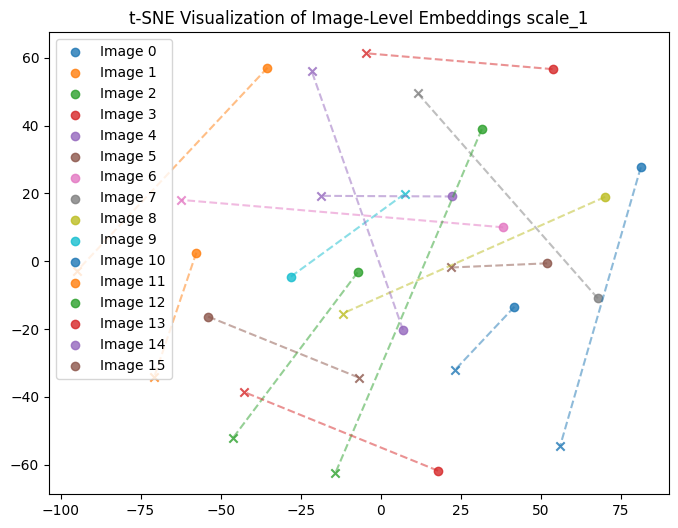

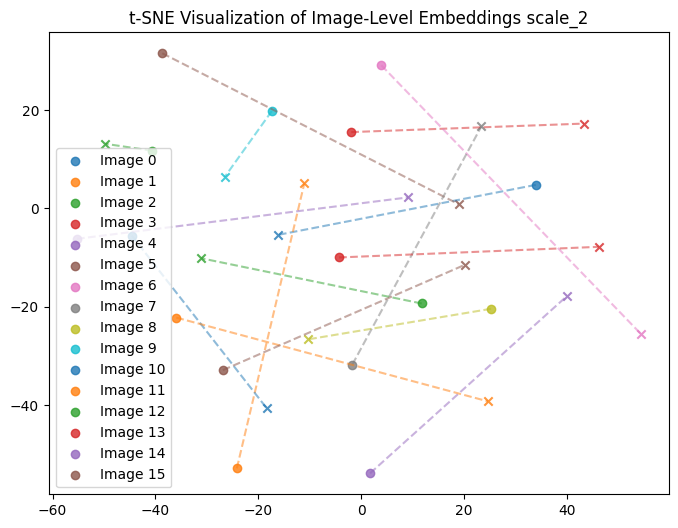

In [6]:


import matplotlib.pyplot as _plt
import numpy as _np
import sklearn.manifold as _manifold
import torch as _torch
import torch.nn as _nn

B, P, E = 16, 64, 128  # Example batch size, patches, embedding dim
x1 = torch.randn(B, P, E)  # Simulated patch embeddings for first view
x2 = torch.randn(B, P, E)  # Simulated patch embeddings for second view
x3 = torch.randn(B, P, E)  # Simulated patch embeddings for third view
x4 = torch.randn(B, P, E)  # Simulated patch embeddings for fourth view
title = "t-SNE Visualization of Image-Level Embeddings"

z1 = {
    'scale_1': x1,
    'scale_2': x3,
}
z2 = {
    'scale_1': x2,
    'scale_2': x4,
}

scales = z1.keys()
assert scales == z2.keys(), "Scale names do not match."

with _torch.no_grad():
    for scale in scales:
        x1 = z1[scale]
        x2 = z2[scale]

        B, P, E = x1.shape  # Batch, Patches, Embedding Dim

        # Compute mean patch embedding per image [B, E]
        x1_avg = x1.mean(dim=1).cpu().numpy()  # Averaging over patches
        x2_avg = x2.mean(dim=1).cpu().numpy()

        # Combine embeddings for t-SNE visualization [2B, E]
        embeddings = _np.concatenate([x1_avg, x2_avg], axis=0)

        # Create labels: Each image gets a unique label
        labels = _np.concatenate([_np.arange(B), _np.arange(B)])  # Shape: [2B]

        # Apply t-SNE
        tsne = _manifold.TSNE(n_components=2, perplexity=10, random_state=42)
        embeddings_2d = tsne.fit_transform(embeddings)

        # Define a distinct color for each image
        cmap = _plt.get_cmap("tab10")  # "tab10" has 10 distinct colors
        colors = [cmap(i % 10) for i in range(B)]  # Assign each image a unique color

        # Plot
        _plt.figure(figsize=(8, 6))

        for i in range(B):  # Each image
            idx_x1, idx_x2 = i, B + i  # First and second augmentation indices
            color = colors[i]  # Unique color for this image

            # Scatter points
            _plt.scatter(embeddings_2d[idx_x1, 0], embeddings_2d[idx_x1, 1], color=color, label=f'Image {i}',
                         alpha=0.8,
                         marker='o')
            _plt.scatter(embeddings_2d[idx_x2, 0], embeddings_2d[idx_x2, 1], color=color, alpha=0.8, marker='x')

            # Draw line connecting views of the same image
            _plt.plot([embeddings_2d[idx_x1, 0], embeddings_2d[idx_x2, 0]],
                      [embeddings_2d[idx_x1, 1], embeddings_2d[idx_x2, 1]],
                      color=color, alpha=0.5, linestyle="--")

        _plt.legend()
        _plt.title(f'{title} {scale}')
        _plt.show()